# PyVBMC Example 4: Multiple runs as validation

Here we explore running PyVBMC multiple times in order to validate the results: if the final variational posteriors obtained from several different initial points are consistent, we can be more confident that the results are correct.

This notebook is Part 4 of a series of notebooks in which we present various example usages for VBMC with the PyVBMC package. The code used in this example is available as a script [here](https://github.com/acerbilab/pyvbmc/blob/main/examples/scripts/pyvbmc_example_4_full_code.py).

In [1]:
import numpy as np
import scipy.stats as scs
from scipy.optimize import minimize
from pyvbmc import VBMC
import matplotlib.pyplot as plt

## 1. Model definition

We use the same toy target function as in Example 1, a broad [Rosenbrock's banana function](https://en.wikipedia.org/wiki/Rosenbrock_function) in $D = 2$, with unbounded parameters:

In [2]:
D = 2  # We'll use a 2-D problem for a quicker demonstration
prior_mu = np.zeros(D)
prior_var = 3 * np.ones(D)


def log_prior(theta):
    """Multivariate normal prior on theta."""
    cov = np.diag(prior_var)
    return scs.multivariate_normal(prior_mu, cov).logpdf(theta)


# log-likelihood (Rosenbrock)
def log_likelihood(theta):
    """D-dimensional Rosenbrock's banana function."""
    theta = np.atleast_2d(theta)

    x, y = theta[:, :-1], theta[:, 1:]
    return -np.sum((x**2 - y) ** 2 + (x - 1) ** 2 / 100, axis=1)


# Full model:
def log_joint(theta, data=np.ones(D)):
    """log-density of the joint distribution."""
    return log_likelihood(theta) + log_prior(theta)


LB = np.full((1, D), -np.inf)  # Lower bounds
UB = np.full((1, D), np.inf)  # Upper bounds
PLB = np.full((1, D), prior_mu - np.sqrt(prior_var))  # Plausible lower bounds
PUB = np.full((1, D), prior_mu + np.sqrt(prior_var))  # Plausible upper bounds
options = {
    "max_fun_evals": 50 * D  # Slightly reduced from 50 * (D + 2), for speed
}

## 2. Validation
For validation, we recommend running PyVBMC 3-4 times from different initial points:

In [3]:
np.random.seed(42)
n_runs = 3
vps, elbos, elbo_sds, success_flags, result_dicts = [], [], [], [], []
for i in range(n_runs):
    print(f"PyVBMC run {i} of {n_runs}")

    # Determine initial point x0:
    if i == 0:
        x0 = prior_mu  # First run, start from prior mean
    else:
        x0 = np.random.uniform(PLB, PUB)  # Other runs, randomize
    # Preliminary maximum a posteriori (MAP) estimation:
    x0 = minimize(
        lambda t: -log_joint(t),
        x0.ravel(),  # minimize expects 1-D input for initial point x0
        bounds=[(-np.inf, np.inf), (-np.inf, np.inf)],
    ).x

    # Run PyVBMC:
    vbmc = VBMC(
        log_joint,
        x0,
        LB,
        UB,
        PLB,
        PUB,
        options=options,
    )
    vp, results = vbmc.optimize()

    # Record the results:
    vps.append(vp)
    elbos.append(results["elbo"])
    elbo_sds.append(results["elbo_sd"])
    success_flags.append(results["success_flag"])
    result_dicts.append(results)

PyVBMC run 0 of 3
Reshaping x0 to row vector.
Beginning variational optimization assuming EXACT observations of the log-joint.
PyVBMC is using standard performance settings. You can optionally tune these for your machine by running pyvbmc.calibrate(). Calibration takes tens of seconds and does not evaluate your model.
Performance settings: standard settings.
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
     0         10          -1.24         1.21    154443.24        2        inf     start warm-up
     1         15          -1.84         0.08         5.07        2        inf     
     2         20          -1.81         0.01         0.16        2       3.77     
     3         25          -1.81         0.00         0.00        2      0.046     
     4         30          -1.82         0.00         0.00        2     0.0678     end warm-up
     5         35          -1.79         0.00         0.00        2      0.165     
     6         40    

We now perform some diagnostic checks on the variational solution. First, we check that the ELBO's from different runs are close to each other (i.e. with a difference much smaller than 1):

In [4]:
print(np.array(elbos))

[-1.56573439 -1.54152363 -1.53294045]


Then, we check that the variational posteriors from distinct runs are similar. As a measure of similarity, we compute the Kullback-Leibler divergence between each pair:

In [5]:
kl_matrix = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(i, n_runs):
        # The `kl_div` method computes the divergence in both directions:
        kl_ij, kl_ji = vps[i].kl_div(vp2=vps[j])
        kl_matrix[i, j] = kl_ij
        kl_matrix[j, i] = kl_ji

Note that the KL divergence is asymmetric, so we have an asymmetric matrix:

In [6]:
print(kl_matrix)

[[-0.          0.09047329  0.0799328 ]
 [ 0.12595337 -0.          0.02015134]
 [ 0.16199972  0.01950154 -0.        ]]


Ideally, we want all KL divergence matrix entries to be much smaller than 1. For a qualitative validation, we recommend a visual inspection of the posteriors:

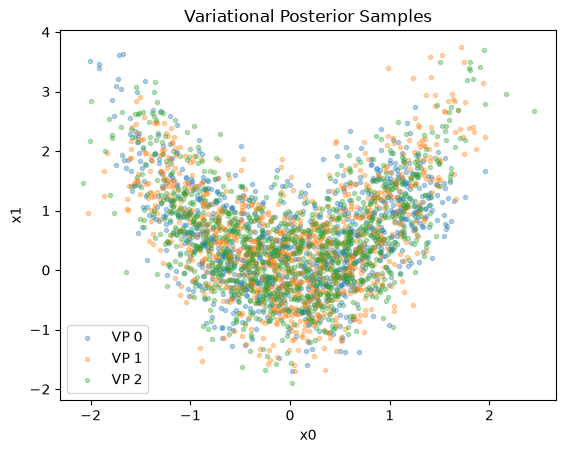

In [7]:
for i, vp in enumerate(vps):
    samples, __ = vp.sample(1000)
    plt.scatter(
        samples[:, 0],
        samples[:, 1],
        alpha=1 / len(vps),
        marker=".",
        label=f"VP {i}",
    )
plt.title("""Variational Posterior Samples""")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend();

We can also check that convergence was achieved in all runs, according to PyVBMC (we want `success_flag = True` for each run):

In [8]:
print(success_flags)

[True, True, True]


Finally, we can pick the variational solution with highest ELCBO (the lower confidence bound on the ELBO).

In [9]:
beta_lcb = 3.0  # Standard confidence parameter (in standard deviations)
# beta_lcb = 5.0  # This is more conservative
elcbos = np.array(elbos) - beta_lcb * np.array(elbo_sds)
idx_best = np.argmax(elcbos)
print(idx_best)

2


The `VariationalPosterior` class implements `save` and `load` methods, similar to `VBMC` (as we saw in Example 3). We'll save this best posterior to a file, so we can compare it against our results in Example 6:

In [10]:
vps[idx_best].save("noise_free_vp.pkl", overwrite=True)

## 3. Conclusions

In this notebook, we have shown you some techniques to validate the results of PyVBMC by comparing statistics across multiple runs.

In the next notebook, we will discuss how to specify prior distributions with PyVBMC.

## Acknowledgments

Work on the PyVBMC package is supported by the Research Council of Finland (grants 356498 and 358980 to Luigi Acerbi) and its Flagship programme: [Finnish Center for Artificial Intelligence FCAI](https://fcai.fi/).